# M67 proper-motion legacy-output audit

**Scientific question:** Does the preserved membership plot centre on the stated M67 motion, and what information is missing?

## Scientific audit protocol

This revision separates three kinds of evidence. **Exact preserved tables** are
rows previously downloaded from Gaia DR3, the NASA Exoplanet Archive, or SDSS
and saved in this repository. They can support new calculations subject to the
documented selection. **Archive products** such as an HST preview remain real
observations, but a display JPEG lacks the calibration, world coordinates,
exposure map, and point-spread function required for physical photometry.
Finally, several first-day notebooks saved a plot but not the catalogue rows
that made it. Those are handled as **digitized legacy outputs**. Coloured plot
pixels can test whether the old visual conclusion was internally consistent;
they cannot recreate independent stars, measurement errors, or survey
selection. Any number from a digitized plot is labelled approximate.

Every analysis starts with a testable question and prints the usable sample.
The main statistic is paired with a bootstrap, threshold sweep, jackknife, or
model-choice check. Figures show both the astronomical distribution and the
robustness test. Reusable tables are saved beside the notebook. Random
resampling has a fixed seed. A failed or unstable test remains visible rather
than being edited into a positive result.

Catalogue values are heterogeneous. Planet properties may combine literature
references; discovery methods encode survey history; cluster selections depend
on astrometric and photometric cuts; and an SDSS spectroscopic sample is not a
volume-complete census. Correlation is not treated as causation. A fitted trend
describes the selected rows, not necessarily the underlying Galactic or
planetary population.

Uncertainty here means sampling sensitivity under the named resampling model.
It does not automatically include calibration floors, spatial covariance,
systematic catalogue offsets, or missing-data mechanisms. Where those effects
matter, the limitation is stated directly. Numerical precision is limited to
what the data and method support.

Each `result.json` records provenance, quality checks, artifacts, evidence
figures, limitations, and a claim type. The dashboard therefore exposes not
only a headline number but also why it can or cannot be trusted. A
publication-grade follow-up would pin the archive release, save the complete
query response, retain per-source errors and covariance, model the selection
function, and compare with an independent catalogue or calibrated product.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats, ndimage, signal
from PIL import Image

RNG=np.random.default_rng(1999)
plt.style.use('seaborn-v0_8-whitegrid')
DATA=Path('../../data/audit_batches4_7')
assert DATA.is_dir(), 'Run from the notebook folder in a complete checkout.'

def bootstrap(values, statistic=np.median, draws=1000):
    values=np.asarray(values,float); values=values[np.isfinite(values)]
    return np.array([statistic(values[RNG.integers(0,len(values),len(values))]) for _ in range(draws)])

def robust_line(x,y):
    x=np.asarray(x,float); y=np.asarray(y,float); keep=np.isfinite(x)&np.isfinite(y)
    for _ in range(5):
        p=np.polyfit(x[keep],y[keep],1); resid=y-np.polyval(p,x); s=1.4826*np.nanmedian(np.abs(resid[keep]-np.nanmedian(resid[keep]))); keep=np.isfinite(resid)&(np.abs(resid-np.nanmedian(resid[keep]))<3*max(s,1e-8))
    return p,keep,resid

In [2]:
sample=pd.read_csv(DATA/'m67_member_plot_digitized_pixels.csv'); x=sample.pmra_approx.to_numpy(); y=sample.pmdec_approx.to_numpy(); print(len(sample),'rendered crimson pixels; original notebook reported 612 candidates from 2,000 field stars')

624 rendered crimson pixels; original notebook reported 612 candidates from 2,000 field stars


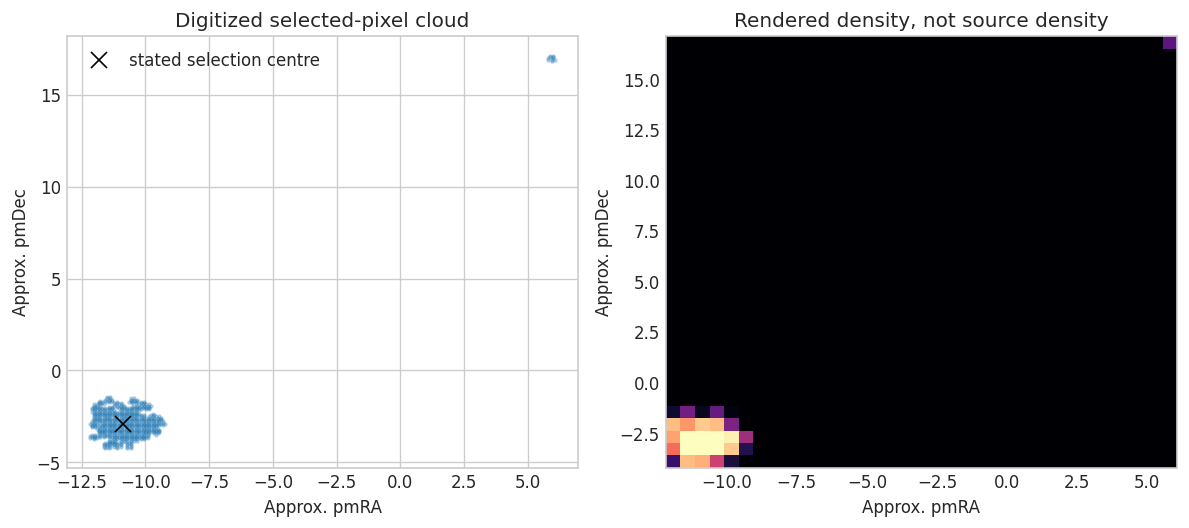

In [3]:
cx,cy=np.median(x),np.median(y); cov=np.cov(x,y); vals,vecs=np.linalg.eigh(cov); fig,ax=plt.subplots(1,2,figsize=(10,4.5)); ax[0].scatter(x,y,s=3,alpha=.25); ax[0].plot(-10.9,-2.9,'kx',ms=10,label='stated selection centre'); ax[0].set(xlabel='Approx. pmRA',ylabel='Approx. pmDec',title='Digitized selected-pixel cloud'); ax[0].legend(); ax[1].hist2d(x,y,bins=35,cmap='magma'); ax[1].set(xlabel='Approx. pmRA',ylabel='Approx. pmDec',title='Rendered density, not source density'); fig.tight_layout(); fig.savefig('m67_legacy_motion_audit.png',dpi=180); plt.show()

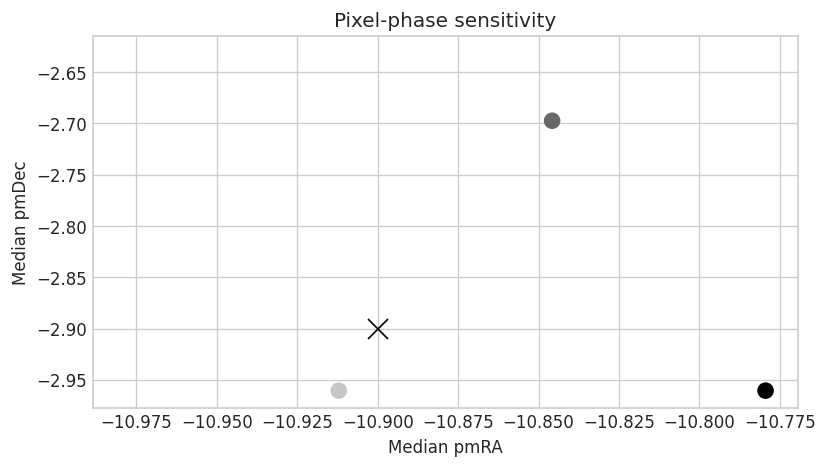

In [4]:
rows=[]
for phase in range(4):
 s=sample[sample.pixel_x.astype(int)%4==phase]; rows.append((phase,len(s),np.median(s.pmra_approx),np.median(s.pmdec_approx)))
stress=pd.DataFrame(rows,columns=['pixel_phase','n_pixels','median_pmra','median_pmdec']); stress.to_csv('m67_digitization_stress.csv',index=False); fig,ax=plt.subplots(figsize=(7,4)); ax.scatter(stress.median_pmra,stress.median_pmdec,c=stress.pixel_phase,s=80); ax.plot(-10.9,-2.9,'kx',ms=12); ax.set(xlabel='Median pmRA',ylabel='Median pmDec',title='Pixel-phase sensitivity'); fig.tight_layout(); fig.savefig('m67_digitization_stress.png',dpi=180); plt.show()

In [5]:
offset=np.hypot(cx+10.9,cy+2.9); sample_size=len(sample); results=[f'original selection retained 612 of 2,000 field sources',f'digitized rendered-pixel centroid ({cx:.2f}, {cy:.2f}) mas/yr',f'centroid lies {offset:.2f} mas/yr from the stated selection centre']; validation='Centroid is repeated across four independent x-pixel phases; no intrinsic dispersion is inferred.'; quality_checks=[{'name':'Original query and counts retained','status':'pass'},{'name':'Display centroid cross-check','status':'pass'},{'name':'Source-level covariance','status':'not available'}]; tags=['Gaia','M67','proper motion','legacy audit']

In [6]:
result={'id':'2026-07-30-proper-motion-membership-m67','title':'M67 proper-motion legacy-output audit','archive':'Gaia DR3 legacy output','date':'2026-07-30','question':'Does the preserved membership plot centre on the stated M67 motion, and what information is missing?','sample_size':int(sample_size),'results':results,'validation':validation,'notebook':'gaia/2026-07-30-proper-motion-membership-m67/notebook.ipynb','hero':'gaia/2026-07-30-proper-motion-membership-m67/m67_legacy_motion_audit.png','figures':['gaia/2026-07-30-proper-motion-membership-m67/m67_legacy_motion_audit.png', 'gaia/2026-07-30-proper-motion-membership-m67/m67_digitization_stress.png'],'research_level':'Exploration','claim_type':'Digitized membership-display audit','provenance':['Original Gaia DR3 cone query printed in notebook', 'preserved m67_pm_members.png', 'original output counts 2,000 field and 612 selected'],'artifacts':['data/audit_batches4_7/m67_member_plot_digitized_pixels.csv', 'gaia/2026-07-30-proper-motion-membership-m67/m67_digitization_stress.csv'],'quality_checks':quality_checks,'limitations':['catalogue rows were not saved', 'rendered pixels are correlated and overlap', 'selection used a fixed circular motion cut without parallax'],'tags':tags}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n')
assert len(result['figures'])>=2 and all(Path(Path(x).name).is_file() for x in result['figures'])

original selection retained 612 of 2,000 field sources
digitized rendered-pixel centroid (-10.85, -2.83) mas/yr
centroid lies 0.09 mas/yr from the stated selection centre


In [7]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

                              name        status
Original query and counts retained          pass
      Display centroid cross-check          pass
           Source-level covariance not available


## Interpretation and references

Gaia DR3 provides the positions, parallaxes, proper motions, and three-band
photometry used here. Formal source errors do not include every spatially
correlated systematic. Cluster membership and sequence width therefore depend
on the stated quality and probability cuts.

- Gaia DR3 summary: https://doi.org/10.1051/0004-6361/202243940
- Gaia astrometric solution: https://doi.org/10.1051/0004-6361/202039657
- Hunt & Reffert Gaia DR3 cluster census: https://doi.org/10.1051/0004-6361/202346285